# Tahapan Pembuatan Digital Twin SEM (Struktur & Metode, bukan Hasil Strategi)

`SEM_Digital_Twin_Demo.ipynb` menunjukkan **hasil** — angka DP/GA/Fuzzy/MPC, skor Art. 54e, driving
line — tapi tidak ada notebook yang menjelaskan **bagaimana digital twin itu sendiri dibangun**: dari
data mentah GPS/datasheet sampai jadi satu forward simulator yang bisa dipanggil optimizer manapun.
Notebook ini mengisi celah itu — jalan-jalan (walkthrough) tahap-per-tahap konstruksi `digital_twin/`,
bukan strategi yang dijalankan di atasnya.

**Perbedaan penting**: DP/GA/PSO/CMA-ES/MPC/Fuzzy (`optimize_*.py`, `mpc.py`, `fuzzy_strategy.py`)
semuanya BUKAN bagian dari digital twin — mereka adalah *strategy layer* yang memanggil
`simulate.simulate()` berulang kali sebagai fungsi fitness/environment (lihat docstring masing-masing
file: "Evaluated via simulate.py as the fitness function"). Digital twin sendiri berhenti di titik
"diberi satu strategi kecepatan + satu kondisi cuaca + satu kombinasi motor/FC, hasilkan telemetri
fisik yang realistis" — itulah yang dibangun di sini.

**Software/library:** Python murni untuk semua fisika (`digital_twin.config/track/weather/vehicle/
powertrain/simulate/telemetry/hybrid_energy`), NumPy untuk operasi tervektorisasi, Pandas untuk tabel,
SciPy (`cKDTree`) untuk join spasial nearest-neighbor, Matplotlib untuk semua visualisasi. Simulator inti
(`simulate.simulate()`) sendiri adalah **loop Python eksplisit per-titik**, bukan tervektorisasi —
dijelaskan alasannya di Tahap 5.

In [1]:
import os, sys, math, re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from digital_twin import config
from digital_twin import track as track_mod
from digital_twin import weather as weather_mod
from digital_twin import vehicle as vehicle_mod
from digital_twin import powertrain
from digital_twin import simulate as sim_mod
from digital_twin import telemetry as telemetry_mod
from digital_twin import hybrid_energy

_rc = {
    'figure.facecolor': '#0d1117', 'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d', 'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e', 'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9', 'grid.color':       '#21262d',
    'grid.linestyle':   '--',      'grid.alpha':        0.6,
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
}
plt.rcParams.update(_rc)

print("Library dimuat. Working directory:", os.getcwd())

Library dimuat. Working directory: C:\Users\Terano\Downloads\Final_Project


## 0. Peta Alur Pembuatan

Lima modul input (data track terukur, model cuaca, dinamika kendaraan, powertrain) mengalir ke SATU
forward simulator, yang keluarannya di-skor lewat Art. 54e. Strategy layer (DP/GA/PSO/CMA/MPC/Fuzzy)
memanggil simulator itu berulang-ulang dari LUAR — itu sebabnya panahnya putus-putus, dan hasilnya ada
di notebook lain, bukan di sini.

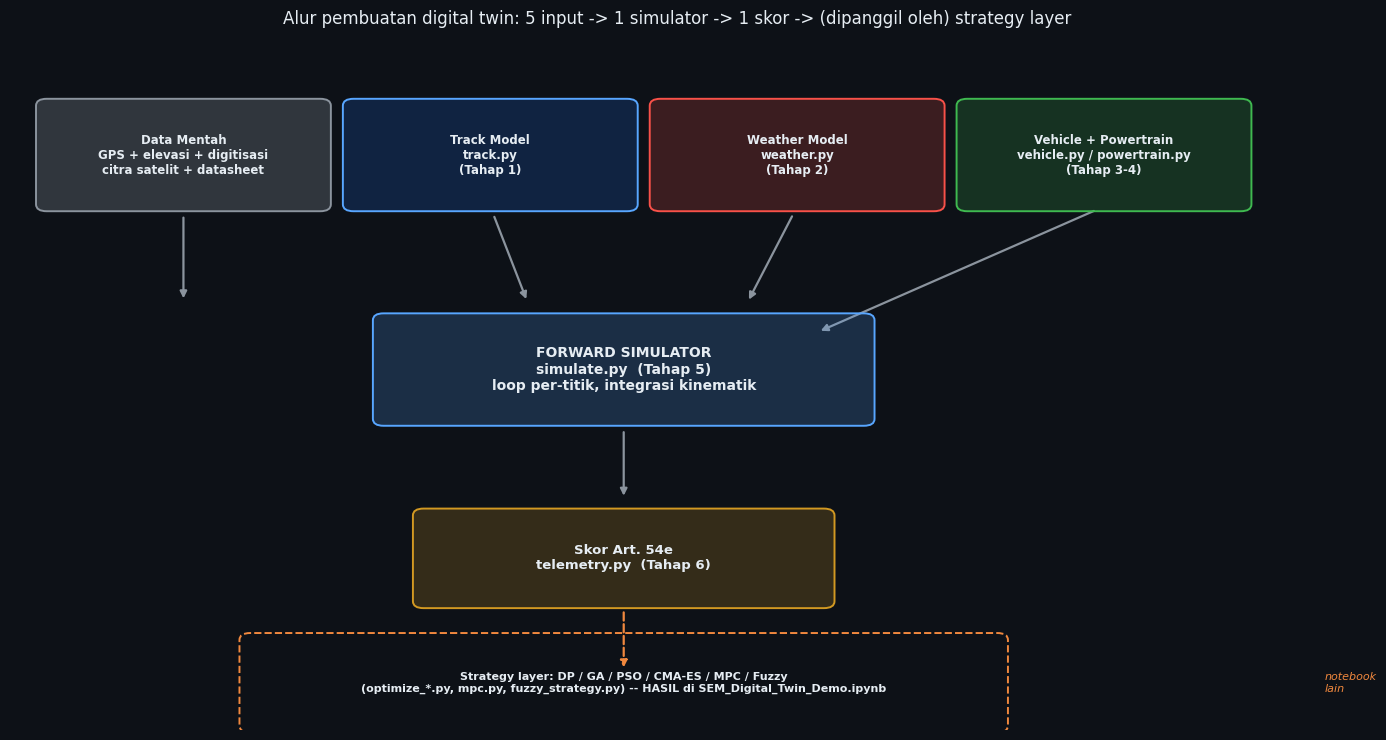

In [2]:
fig, ax = plt.subplots(figsize=(14, 7.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis("off")

box_style = dict(boxstyle="round,pad=0.08", linewidth=1.4)

def draw_box(x, y, w, h, text, fc, ec, fontsize=9.5, style="-"):
    b = mpatches.FancyBboxPatch((x - w / 2, y - h / 2), w, h, facecolor=fc, edgecolor=ec,
                                 linestyle=style, **box_style, zorder=3)
    ax.add_patch(b)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize, color="#e6edf3",
            fontweight="bold", zorder=4)

def arrow(x0, y0, x1, y1, style="-", color="#8b949e"):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=1.6, linestyle=style,
                                 shrinkA=8, shrinkB=8), zorder=2)

inputs = [
    (1.3, 6.7, "Data Mentah\nGPS + elevasi + digitisasi\ncitra satelit + datasheet"),
    (3.6, 6.7, "Track Model\ntrack.py\n(Tahap 1)"),
    (5.9, 6.7, "Weather Model\nweather.py\n(Tahap 2)"),
    (8.2, 6.7, "Vehicle + Powertrain\nvehicle.py / powertrain.py\n(Tahap 3-4)"),
]
colors_in = ["#30363d", "#1f6feb33", "#f8514933", "#3fb95033"]
edges_in = ["#8b949e", "#58a6ff", "#f85149", "#3fb950"]
for (x, y, t), fc, ec in zip(inputs, colors_in, edges_in):
    draw_box(x, y, 2.05, 1.15, t, fc, ec, fontsize=8.5)

arrow(1.3, 6.1, 1.3, 4.9)
arrow(3.6, 6.1, 3.9, 4.9)
arrow(5.9, 6.1, 5.5, 4.9)
arrow(8.2, 6.1, 6.0, 4.6)

draw_box(4.6, 4.2, 3.6, 1.15, "FORWARD SIMULATOR\nsimulate.py  (Tahap 5)\nloop per-titik, integrasi kinematik",
         "#58a6ff33", "#58a6ff", fontsize=10)

arrow(4.6, 3.6, 4.6, 2.6)
draw_box(4.6, 2.0, 3.0, 1.0, "Skor Art. 54e\ntelemetry.py  (Tahap 6)", "#d2992233", "#d29922", fontsize=9.5)

arrow(4.6, 1.5, 4.6, 0.6, style="--", color="#f0883e")
draw_box(4.6, 0.0 + 0.55, 5.6, 1.0,
         "Strategy layer: DP / GA / PSO / CMA-ES / MPC / Fuzzy\n"
         "(optimize_*.py, mpc.py, fuzzy_strategy.py) -- HASIL di SEM_Digital_Twin_Demo.ipynb",
         "#00000000", "#f0883e", fontsize=8, style="--")

ax.text(9.85, 0.55, "notebook\nlain", ha="left", va="center", fontsize=8, color="#f0883e", style="italic")

ax.set_title("Alur pembuatan digital twin: 5 input -> 1 simulator -> 1 skor -> (dipanggil oleh) strategy layer",
              fontsize=12, color="#e6edf3", pad=14)
plt.tight_layout()
plt.savefig("assets/plot_dt_pipeline.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

## 1. Tahap 0 — Konstanta & Sistem Kepercayaan Data (`config.py`)

Sebelum fisika apapun ditulis, setiap angka yang dipakai digital twin ini ditaruh di satu file
(`config.py`) dan ditandai tingkat kepercayaannya secara eksplisit di komentar sebelah nilainya:

- **MEASURED** — langsung dari datasheet/parameter PDF tim atau pengukuran fisik bersih.
- **RULE-DERIVED** — dihitung dari pasal rulebook 2026 (Chapter I/II), bukan diukur.
- **PLACEHOLDER** — estimasi/asumsi karena data aslinya belum ada; aman ditimpa begitu sub-tim terkait
  (VD/Motor/FC/EP/BnF) memberi angka nyata.

Ini bukan sekadar dokumentasi — tag ini yang membedakan "digital twin ini akurat di sini" vs "digital
twin ini menebak di sini", dan setiap notebook hasil (termasuk `SEM_Digital_Twin_Demo.ipynb`) mewarisi
ketidakpastian itu dari konstanta yang mereka pakai.

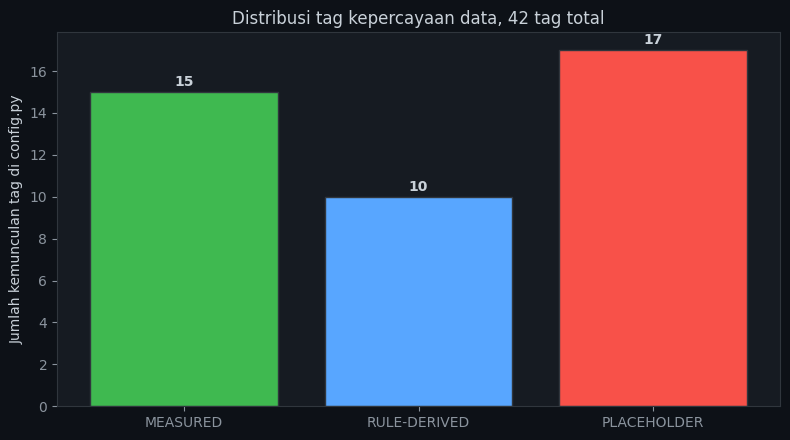

Catatan: dihitung dari kemunculan tag di source SETELAH docstring modul (legend
tidak lagi ikut terhitung), termasuk konstanta yang namanya sendiri berakhiran
_PLACEHOLDER. Masih proporsi per-KEMUNCULAN (satu blok komentar bisa menaungi
beberapa konstanta terkait, misal MPC_THETA_DEFAULT), bukan audit resmi 1:1.

PLACEHOLDER     17
MEASURED        15
RULE-DERIVED    10


In [3]:
with open("digital_twin/config.py", encoding="utf-8") as f:
    config_lines = f.readlines()

# Skip the module docstring itself -- it DEFINES what MEASURED/RULE-DERIVED/
# PLACEHOLDER mean in prose, and naively regexing the whole file counted that
# legend text as if it were a tag on a real constant. Body starts after the
# closing triple-quote of the docstring.
body_start = next(i for i, l in enumerate(config_lines) if l.strip() == '"""' and i > 0) + 1
config_src = "".join(config_lines[body_start:])

# Two patterns needed: the usual "# TAG" comment style, AND constants literally
# NAMED with a "_PLACEHOLDER" suffix (e.g. BUFFER_CAPACITY_WH_PLACEHOLDER) --
# \b does not break on "_", so a plain \bPLACEHOLDER\b misses those entirely.
tag_pattern = re.compile(r"\b(MEASURED(?:-CFD|-derived)?|RULE-DERIVED|CONSERVATIVE PLACEHOLDER|PLACEHOLDER|CALCULATED)\b|_PLACEHOLDER\b")
tags = [m.group(0) for m in tag_pattern.finditer(config_src)]

def normalize(t):
    tl = t.upper()
    if "PLACEHOLDER" in tl:
        return "PLACEHOLDER"
    if "MEASURED" in tl:
        return "MEASURED"
    if "RULE-DERIVED" in tl:
        return "RULE-DERIVED"
    return "CALCULATED"

norm_tags = [normalize(t) for t in tags]
counts = pd.Series(norm_tags).value_counts()

fig, ax = plt.subplots(figsize=(8, 4.5))
tag_colors = {"MEASURED": "#3fb950", "RULE-DERIVED": "#58a6ff", "CALCULATED": "#d29922", "PLACEHOLDER": "#f85149"}
order = [t for t in ["MEASURED", "RULE-DERIVED", "CALCULATED", "PLACEHOLDER"] if t in counts.index]
vals = [counts[t] for t in order]
colors = [tag_colors[t] for t in order]
bars = ax.bar(order, vals, color=colors, edgecolor="#30363d")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.3, str(v), ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Jumlah kemunculan tag di config.py")
ax.set_title(f"Distribusi tag kepercayaan data, {len(tags)} tag total")
plt.tight_layout()
plt.savefig("assets/plot_dt_config_tags.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

print("Catatan: dihitung dari kemunculan tag di source SETELAH docstring modul (legend")
print("tidak lagi ikut terhitung), termasuk konstanta yang namanya sendiri berakhiran")
print("_PLACEHOLDER. Masih proporsi per-KEMUNCULAN (satu blok komentar bisa menaungi")
print("beberapa konstanta terkait, misal MPC_THETA_DEFAULT), bukan audit resmi 1:1.")
print()
print(counts.to_string())

## 2. Tahap 1 — Model Track (`track.py`)

Track Lusail tidak datang sebagai satu tabel siap pakai. `build_track_profile()` menggabungkan **tiga**
sumber data berbeda menjadi satu DataFrame per-titik:

1. **Backbone GPS+elevasi** (`data/sem_apme_2025-track_coordinates.csv`) — jejak GPS mentah Shell +
   ketinggian, ~1 titik/meter.
2. **Tabel tikungan** (`data/turns.csv`) — hasil ekstraksi manual dari `track_analysis_final.csv`
   (radius minimum & `v_safe` per tikungan, $v_{safe}=\sqrt{\mu g R}$).
3. **Lebar corridor terdigitisasi** (`data/track_edges_imagery.csv`) — dari citra satelit Esri
   (~0.27 m/px), di-*join* ke backbone lewat **nearest-neighbor spasial** (`scipy.spatial.cKDTree`)
   karena kedua dataset punya arc-length sendiri-sendiri yang tidak sama persis.

Langkah komputasi per titik:
- **Heading** — *forward compass bearing* standar (`atan2` dari selisih lat/lon ke titik berikutnya).
- **Grade (%)** — *centered finite-difference* atas jendela ±20 m, DIDAHULUI pelicinan ringan (moving
  average ±50 m) untuk membuang staircase kuantisasi 0.1 m kolom altitude GPS mentah sebelum
  diturunkan (differentiate) — tanpa ini turunannya jadi gerigi palsu, bukan gradien jalan sungguhan.

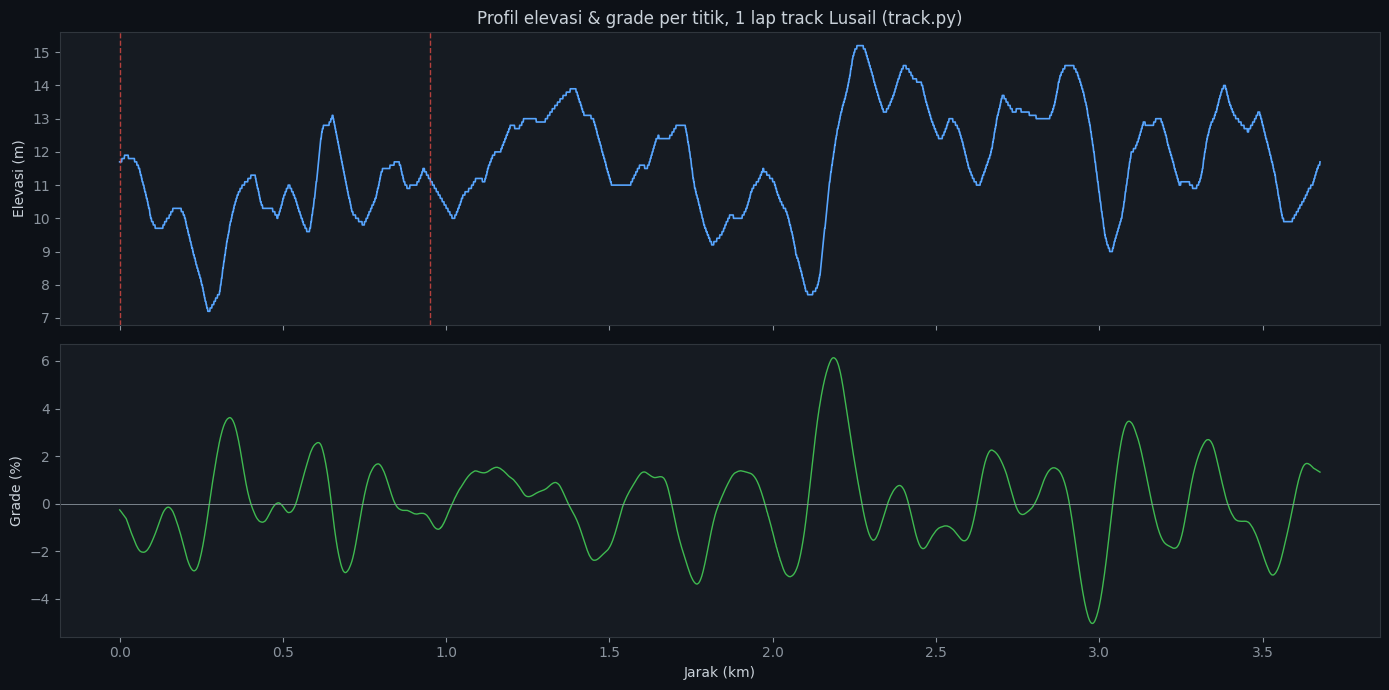

Titik profil: 3677 | di zona tikungan: 1359 (37.0%)
Lebar corridor terukur: min 6.6 m / median 13.6 m / max 26.9 m
Tikungan tersempit: r_min=37.6 m -> v_safe=63.7 km/h


In [4]:
profile = track_mod.build_track_profile(save=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.plot(profile["distance_km"], profile["altitude_m"], color="#58a6ff", linewidth=1.2)
ax1.set_ylabel("Elevasi (m)")
ax1.set_title("Profil elevasi & grade per titik, 1 lap track Lusail (track.py)")
for _, t in profile[profile["stop_event"]].iterrows():
    ax1.axvline(t["distance_km"], color="#f85149", linestyle="--", linewidth=1, alpha=0.7)

ax2.plot(profile["distance_km"], profile["grade_pct"], color="#3fb950", linewidth=1.0)
ax2.axhline(0, color="#8b949e", linewidth=0.6)
ax2.set_xlabel("Jarak (km)")
ax2.set_ylabel("Grade (%)")
plt.tight_layout()
plt.savefig("assets/plot_dt_track_profile.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

n_turn = (profile["zone_type"] == "turn").sum()
print(f"Titik profil: {len(profile)} | di zona tikungan: {n_turn} ({n_turn/len(profile)*100:.1f}%)")
print(f"Lebar corridor terukur: min {profile['width_m'].min():.1f} m / median {profile['width_m'].median():.1f} m / max {profile['width_m'].max():.1f} m")
turn_only = profile[profile["zone_type"] == "turn"]
print(f"Tikungan tersempit: r_min={turn_only['r_min_m'].min():.1f} m -> v_safe={turn_only.loc[turn_only['r_min_m'].idxmin(), 'v_safe_kmh']:.1f} km/h")

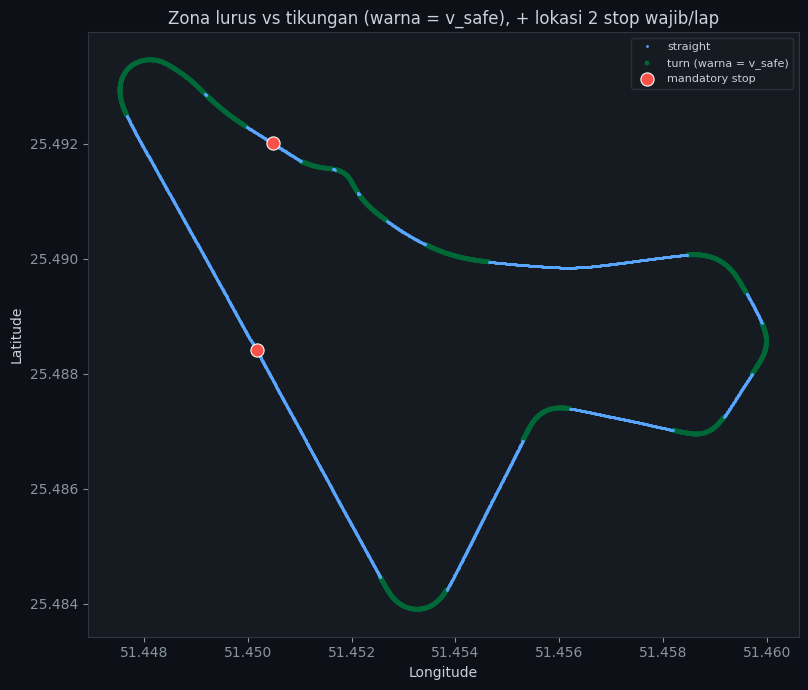

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
straight = profile[profile["zone_type"] == "straight"]
turn = profile[profile["zone_type"] == "turn"]
ax.plot(straight["longitude"], straight["latitude"], ".", color="#58a6ff", markersize=2, label="straight")
ax.scatter(turn["longitude"], turn["latitude"], c=turn["v_safe_kmh"], cmap="RdYlGn", s=6,
           vmin=15, vmax=45, label="turn (warna = v_safe)")
stops = profile[profile["stop_event"]]
ax.scatter(stops["longitude"], stops["latitude"], color="#f85149", s=90, zorder=5,
           edgecolor="white", linewidth=0.8, label="mandatory stop")
ax.set_aspect(1 / math.cos(math.radians(profile["latitude"].mean())))
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Zona lurus vs tikungan (warna = v_safe), + lokasi 2 stop wajib/lap")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("assets/plot_dt_track_zones.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

## 3. Tahap 2 — Model Cuaca (`weather.py`)

Sudah dibahas lengkap (metode, rumus, sumber, heatmap headwind/tailwind) di
**`Weather_Scenario_Analysis.ipynb`** — di sini cukup ringkasan posisinya dalam pipeline: `weather.py`
menghasilkan tiga skenario bernama (`calm`/`typical_january`/`shamal_strong`), masing-masing berupa
sepasang angka (densitas udara ρ, komponen headwind per-heading) yang dikonsumsi `vehicle.drag_force_n()`
di Tahap 3 di bawah. Tidak ada logika baru di sini, cuma dipanggil.

In [6]:
for name, s in weather_mod.SCENARIOS.items():
    rho = weather_mod.air_density(s)
    print(f"{name:16s}: T={s.temperature_c:5.1f}C  RH={s.relative_humidity*100:4.1f}%  "
          f"wind={s.wind_speed_kmh:5.1f} km/h from {s.wind_from_bearing_deg:.0f}deg  ->  rho={rho:.4f} kg/m^3")

calm            : T= 17.5C  RH=65.0%  wind=  9.0 km/h from 351deg  ->  rho=1.2107 kg/m^3
typical_january : T= 17.7C  RH=65.0%  wind= 17.0 km/h from 351deg  ->  rho=1.2098 kg/m^3
shamal_strong   : T= 14.0C  RH=50.0%  wind= 28.0 km/h from 351deg  ->  rho=1.2314 kg/m^3


## 4. Tahap 3 — Dinamika Kendaraan (`vehicle.py`)

Persamaan gerak titik-massa longitudinal: $m \dot v = F_{traksi} - F_{drag} - F_{roll} - F_{grade} -
F_{cornering}$. Empat gaya resistif:

$$F_{drag} = \tfrac{1}{2}\rho \, C_dA(v_{rel}) \, v_{rel}|v_{rel}|
\qquad F_{roll} = C_{rr}\, m g \cos\theta
\qquad F_{grade} = m g \sin\theta$$
$$F_{cornering} = m \cdot \frac{v^2}{R} \cdot k_{scrub} \quad \text{(induced drag dari slip-angle saat menikung, 0 di jalan lurus)}$$

$C_dA(v)$ bukan konstanta tunggal — di-*interpolasi* dari tabel CFD (`config.AERO_CDA_CFD`, hasil Ansys
Fluent tim VD) terhadap **airspeed relatif** $v_{rel}$ (dari Tahap 2), bukan ground speed. Grafik di
bawah menghitung keempat gaya ini langsung dari `vehicle.py` (bukan angka dihafal ulang) pada rentang
kecepatan 0-50 km/h, skenario `typical_january`, membandingkan jalan datar vs tanjakan terjal track
(grade maksimum yang benar-benar ada di profil Tahap 1) vs tikungan tersempit.

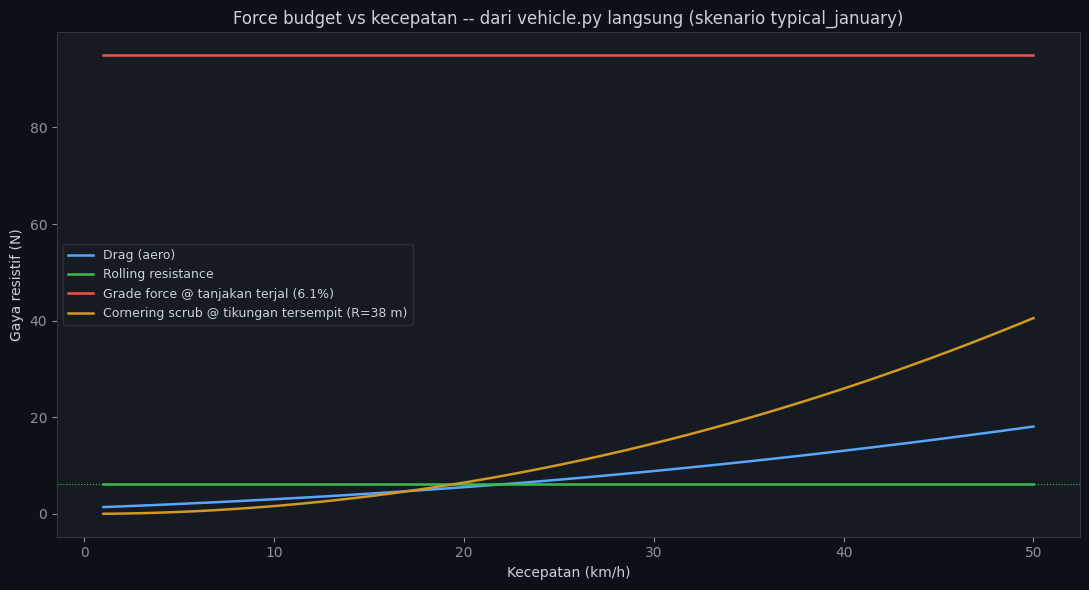

@ 30 km/h flat: drag=8.9 N | roll=6.2 N | grade(climb 6.1%)=94.9 N | cornering(R=38m)=14.6 N


In [7]:
v_sweep = np.linspace(1, 50, 100)
scenario = weather_mod.SCENARIOS["typical_january"]
max_grade = profile["grade_pct"].max()
min_r = turn_only["r_min_m"].min()

f_drag = [vehicle_mod.drag_force_n(v, scenario, 0.0) for v in v_sweep]
f_roll = [vehicle_mod.rolling_resistance_n(0.0) for v in v_sweep]
f_grade_flat = [vehicle_mod.grade_force_n(0.0) for v in v_sweep]
f_grade_climb = [vehicle_mod.grade_force_n(max_grade) for v in v_sweep]
f_corner = [vehicle_mod.cornering_drag_n(v, min_r) for v in v_sweep]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(v_sweep, f_drag, color="#58a6ff", label="Drag (aero)", linewidth=1.8)
ax.plot(v_sweep, f_roll, color="#3fb950", label="Rolling resistance", linewidth=1.8)
ax.plot(v_sweep, f_grade_climb, color="#f85149", label=f"Grade force @ tanjakan terjal ({max_grade:.1f}%)", linewidth=1.8)
ax.plot(v_sweep, f_corner, color="#d29922", label=f"Cornering scrub @ tikungan tersempit (R={min_r:.0f} m)", linewidth=1.8)
ax.axhline(float(f_roll[0]), color="#3fb950", linestyle=":", linewidth=0.8)
ax.set_xlabel("Kecepatan (km/h)")
ax.set_ylabel("Gaya resistif (N)")
ax.set_title("Force budget vs kecepatan -- dari vehicle.py langsung (skenario typical_january)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("assets/plot_dt_force_budget.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

v_ref = 30.0
print(f"@ {v_ref:.0f} km/h flat: drag={vehicle_mod.drag_force_n(v_ref, scenario, 0.0):.1f} N | "
      f"roll={vehicle_mod.rolling_resistance_n(0.0):.1f} N | "
      f"grade(climb {max_grade:.1f}%)={vehicle_mod.grade_force_n(max_grade):.1f} N | "
      f"cornering(R={min_r:.0f}m)={vehicle_mod.cornering_drag_n(v_ref, min_r):.1f} N")

### 4a. Bagaimana `vehicle.py` benar-benar dipanggil di dalam `simulate.py`

Grafik di atas menunjukkan bentuk gaya-gaya itu terhadap kecepatan, tapi bukan bagaimana
`simulate.py` benar-benar memakainya. Isi loop per-langkah (`simulate.py`, sekitar baris 370
dan lagi di baris 452-455) memanggil PERSIS fungsi yang sama:

```python
f_res = vehicle.resistance_force_n(v_kmh_i, grade_pct[i], scenario, heading_deg[i], r_min_m=r_min_m[i])
...
f_traction = config.MASS_TOTAL_KG * a_applied + f_res
```

`resistance_force_n()` sendiri (lihat `vehicle.py`) hanyalah penjumlahan 4 fungsi gaya yang
sudah dipakai di grafik Tahap 3 -- **bukan rumus baru**, satu fungsi pembungkus saja. Traksi
yang dibutuhkan motor = melawan resistance_force_n() ini DITAMBAH percepatan yang diminta
strategi ($m \cdot a$). Contoh angka konkret (bukan disimulasikan, dipanggil langsung dari
`vehicle.py`) -- mobil di tanjakan sedang, menikung, minta percepatan ringan:

In [8]:
v_ex_kmh = 30.0
grade_ex_pct = 2.0
heading_ex_deg = 45.0
r_min_ex_m = 25.0
a_des_ex_ms2 = 0.3  # percepatan yang diminta strategi (gas ringan)

f_drag_ex = vehicle_mod.drag_force_n(v_ex_kmh, scenario, heading_ex_deg)
f_roll_ex = vehicle_mod.rolling_resistance_n(grade_ex_pct)
f_grade_ex = vehicle_mod.grade_force_n(grade_ex_pct)
f_corner_ex = vehicle_mod.cornering_drag_n(v_ex_kmh, r_min_ex_m)
f_res_ex = vehicle_mod.resistance_force_n(v_ex_kmh, grade_ex_pct, scenario, heading_ex_deg, r_min_m=r_min_ex_m)

print(f"Input: v={v_ex_kmh:.0f} km/h, grade={grade_ex_pct:.1f}%, heading={heading_ex_deg:.0f}deg, r_min={r_min_ex_m:.0f} m")
print(f"  F_drag      = {f_drag_ex:7.2f} N")
print(f"  F_roll      = {f_roll_ex:7.2f} N")
print(f"  F_grade     = {f_grade_ex:7.2f} N")
print(f"  F_cornering = {f_corner_ex:7.2f} N")
print(f"  jumlah manual           = {f_drag_ex + f_roll_ex + f_grade_ex + f_corner_ex:7.2f} N")
print(f"  resistance_force_n()    = {f_res_ex:7.2f} N  <- harus sama persis dengan jumlah manual di atas")

f_traction_ex = config.MASS_TOTAL_KG * a_des_ex_ms2 + f_res_ex
print(f"\nDESIRED percepatan strategi a_des = {a_des_ex_ms2:.2f} m/s^2 (mobil {config.MASS_TOTAL_KG:.0f} kg)")
print(f"  F_traction = MASS_TOTAL_KG * a_des + F_res = {config.MASS_TOTAL_KG:.0f} * {a_des_ex_ms2:.2f} + {f_res_ex:.2f} = {f_traction_ex:.2f} N")
print("  -> angka INI (F_traction) yang diteruskan ke Tahap 4b/5 (powertrain.py) sebagai permintaan daya motor.")

Input: v=30 km/h, grade=2.0%, heading=45deg, r_min=25 m
  F_drag      =    6.48 N
  F_roll      =    6.20 N
  F_grade     =   30.99 N
  F_cornering =   21.94 N
  jumlah manual           =   65.62 N
  resistance_force_n()    =   65.62 N  <- harus sama persis dengan jumlah manual di atas

DESIRED percepatan strategi a_des = 0.30 m/s^2 (mobil 158 kg)
  F_traction = MASS_TOTAL_KG * a_des + F_res = 158 * 0.30 + 65.62 = 113.02 N
  -> angka INI (F_traction) yang diteruskan ke Tahap 4b/5 (powertrain.py) sebagai permintaan daya motor.


## 5. Tahap 4 — Model Powertrain (`powertrain.py`)

Motor dan fuel cell dimodelkan dari kurva efisiensi hasil digitisasi datasheet (`data/motor_candidates.csv`,
`data/fc_candidates.csv`), bukan formula tertutup. `MotorModel.electrical_power_w()` meng-interpolasi
**daya elektrik** langsung dari titik (daya mekanik, daya elektrik) yang dihitung sekali di
`__init__` -- BUKAN meng-interpolasi rasio efisiensi lalu membaginya saat query. Alasannya konkret: baris
pertama tiap datasheet motor berlabuh di (~0 W, 0% efisiensi); interpolasi linear rasio lewat titik
degenerate ini membuat `daya_mekanik/efisiensi` kolaps jadi KONSTAN sepanjang segmen pertama (bug nyata
yang pernah ditemukan, bukan hipotetis) -- terutama parah untuk motor cruise dua-motor yang segmen
degenerate-nya menutupi hampir seluruh rentang operasinya yang memang kecil.

Digital twin ini punya 3 kandidat motor terkonfigurasi + 1 fuel cell default:

powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)


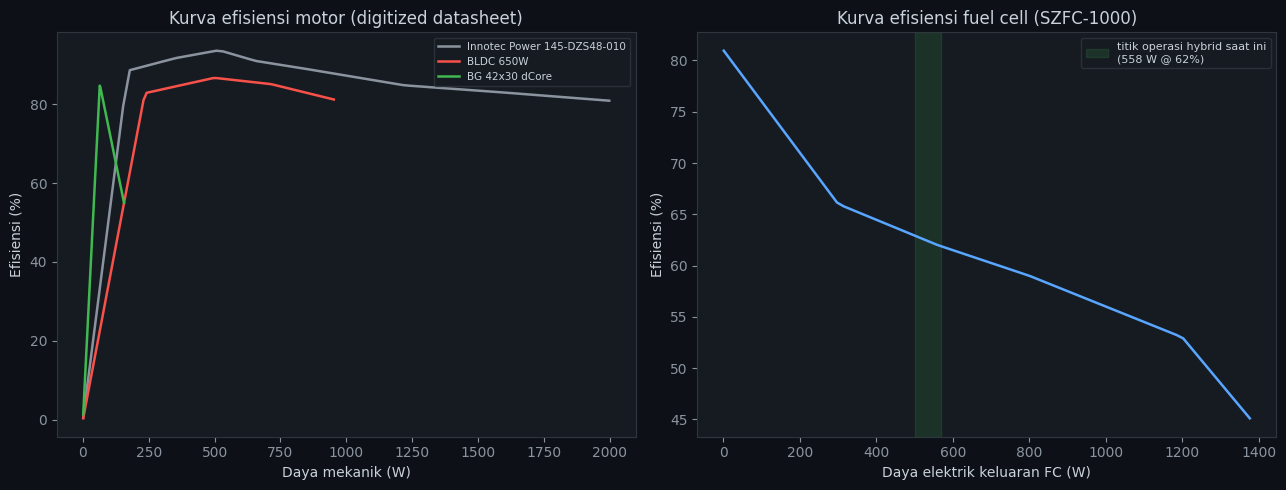

Catatan arsitektur (2026-07, saat ini AKTIF -- lihat hybrid_energy.py):
  FC ditahan di titik operasi stabil 558 W @ 62% efisiensi,
  supercapacitor (3x Maxwell BMOD0058 seri) menyerap transien beban -- kurva efisiensi FC di atas
  masih dipakai model per-langkah versi lama (USE_HYBRID_SUPERCAP=False), tapi TIDAK untuk perhitungan
  H2 default saat ini -- itu di-overwrite oleh hybrid_energy.apply_hybrid() di akhir simulate() (Tahap 6).


In [9]:
motors = powertrain.load_motors()
fc = powertrain.load_fuel_cells()[config.DEFAULT_FC_NAME]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

motor_names = [config.DEFAULT_MOTOR_NAME, config.ACCEL_MOTOR_NAME, config.CRUISE_MOTOR_NAME]
motor_colors = {config.DEFAULT_MOTOR_NAME: "#8b949e", config.ACCEL_MOTOR_NAME: "#f85149", config.CRUISE_MOTOR_NAME: "#3fb950"}
for name in motor_names:
    m = motors[name]
    p_mech = np.linspace(1, m.max_mech_power_w(), 80)
    eff = [m.efficiency_at_power(p) * 100 for p in p_mech]
    ax1.plot(p_mech, eff, color=motor_colors[name], label=name, linewidth=1.8)
ax1.set_xlabel("Daya mekanik (W)")
ax1.set_ylabel("Efisiensi (%)")
ax1.set_title("Kurva efisiensi motor (digitized datasheet)")
ax1.legend(fontsize=7.5)

p_elec = np.linspace(1, fc.table["power_w"].max(), 80)
eff_fc = [fc.efficiency_at_power(p) * 100 for p in p_elec]
ax2.plot(p_elec, eff_fc, color="#58a6ff", linewidth=1.8)
ax2.axvspan(config.FC_HYBRID_BAND_W[0], config.FC_HYBRID_BAND_W[1], color="#3fb950", alpha=0.15,
            label=f"titik operasi hybrid saat ini\n({config.FC_HYBRID_OP_POWER_W:.0f} W @ {config.FC_HYBRID_EFF*100:.0f}%)")
ax2.set_xlabel("Daya elektrik keluaran FC (W)")
ax2.set_ylabel("Efisiensi (%)")
ax2.set_title(f"Kurva efisiensi fuel cell ({config.DEFAULT_FC_NAME})")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("assets/plot_dt_powertrain_curves.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

print("Catatan arsitektur (2026-07, saat ini AKTIF -- lihat hybrid_energy.py):")
print(f"  FC ditahan di titik operasi stabil {config.FC_HYBRID_OP_POWER_W:.0f} W @ {config.FC_HYBRID_EFF*100:.0f}% efisiensi,")
print("  supercapacitor (3x Maxwell BMOD0058 seri) menyerap transien beban -- kurva efisiensi FC di atas")
print("  masih dipakai model per-langkah versi lama (USE_HYBRID_SUPERCAP=False), tapi TIDAK untuk perhitungan")
print("  H2 default saat ini -- itu di-overwrite oleh hybrid_energy.apply_hybrid() di akhir simulate() (Tahap 6).")

### 5a. Melanjutkan contoh 4a: dari `F_traction` sampai `h2_flow_m3_s`

`simulate.py` meneruskan `F_traction` dari 4a lewat rantai fungsi yang PERSIS sama dengan
baris 399/473-495 aslinya:

```python
desired_mech_w = max(0.0, f_traction) * v_ms / DRIVETRAIN_EFFICIENCY
elec_w, clipped = motor.electrical_power_w(desired_mech_w)
p_fc_elec = elec_w / buffer_eff + FC_PARASITIC_LOAD_W
h2_flow = fc.h2_volume_flow_m3_s(p_fc_elec)
```

`electrical_power_w()` juga yang menghasilkan flag `clipped` -- True kalau motor diminta
lebih dari `max_mech_power_w()`-nya, yang lalu memicu power-limit feedback (Tahap 6)
menurunkan `a_applied` supaya mobil tidak "berpura-pura" berakselerasi melebihi kapasitas
powertrain-nya. Contoh dua kasus: permintaan wajar dari 4a, lalu permintaan sengaja
di atas kapasitas motor.

In [10]:
motor = motors[config.DEFAULT_MOTOR_NAME]  # dipakai lagi di sini, sebelum didefinisikan ulang di Tahap 6

v_ex_ms = v_ex_kmh / 3.6
desired_mech_w_ex = max(0.0, f_traction_ex) * v_ex_ms / config.DRIVETRAIN_EFFICIENCY_ASSUMED
elec_w_ex, clipped_ex = motor.electrical_power_w(desired_mech_w_ex)
through_buffer_ex = True  # single-motor mode: selalu lewat buffer (lihat catatan Tahap 5)
buffer_eff_ex = config.POWERTRAIN_BUFFER_EFFICIENCY_ASSUMED if through_buffer_ex else 1.0
p_fc_elec_ex = elec_w_ex / buffer_eff_ex + config.FC_PARASITIC_LOAD_W
h2_flow_ex = fc.h2_volume_flow_m3_s(p_fc_elec_ex)

print("=== Kasus normal (lanjutan 4a) ===")
print(f"desired_mech_w = max(0,{f_traction_ex:.1f}) * {v_ex_ms:.2f} / {config.DRIVETRAIN_EFFICIENCY_ASSUMED:.2f} = {desired_mech_w_ex:.1f} W")
print(f"motor.electrical_power_w() -> {elec_w_ex:.1f} W elektrik  (clipped={clipped_ex}, kapasitas motor {motor.max_mech_power_w():.0f} W mekanik)")
print(f"p_fc_elec = {elec_w_ex:.1f} / {buffer_eff_ex:.2f} (buffer) + {config.FC_PARASITIC_LOAD_W:.0f} (parasitic) = {p_fc_elec_ex:.1f} W")
print(f"fc.h2_volume_flow_m3_s() -> {h2_flow_ex*1e6:.2f} mL/s hidrogen")
print(f"  (catatan: {p_fc_elec_ex:.0f} W ini di atas rating {fc.rated_power_w:.0f} W SZFC-1000 -- tabel efisiensinya")
print("   di-clamp datar di titik terakhir yang terdigitisasi, jadi mL/s ini melebih-lebihkan; skenario")
print("   permintaan setinggi ini justru contoh KONKRET kenapa buffer supercapacitor -- bukan FC saja --")
print("   yang dirancang menyerap transien seperti ini, lihat hybrid_energy.py / catatan arsitektur Tahap 5.)")

print()
print("=== Kasus melebihi kapasitas motor (demonstrasi clipping) ===")
over_mech_w = motor.max_mech_power_w() * 1.5
over_elec_w, over_clipped = motor.electrical_power_w(over_mech_w)
print(f"Diminta {over_mech_w:.0f} W mekanik (1.5x kapasitas {motor.max_mech_power_w():.0f} W)")
print(f"  -> electrical_power_w() clip ke kapasitas maks, clipped={over_clipped}, keluar {over_elec_w:.1f} W")
print("  -> di simulate.py ini memicu power-limit feedback: f_traction_max dihitung ulang dari")
print("     P_max motor, lalu a_applied DIKOREKSI TURUN (baris ~436-441) -- mobil tidak bisa")
print("     berakselerasi melebihi yang powertrain-nya sanggup berikan.")

=== Kasus normal (lanjutan 4a) ===
desired_mech_w = max(0,113.0) * 8.33 / 0.80 = 1177.3 W
motor.electrical_power_w() -> 1382.8 W elektrik  (clipped=False, kapasitas motor 1999 W mekanik)
p_fc_elec = 1382.8 / 0.90 (buffer) + 10 (parasitic) = 1546.4 W
fc.h2_volume_flow_m3_s() -> 318.10 mL/s hidrogen
  (catatan: 1546 W ini di atas rating 1000 W SZFC-1000 -- tabel efisiensinya
   di-clamp datar di titik terakhir yang terdigitisasi, jadi mL/s ini melebih-lebihkan; skenario
   permintaan setinggi ini justru contoh KONKRET kenapa buffer supercapacitor -- bukan FC saja --
   yang dirancang menyerap transien seperti ini, lihat hybrid_energy.py / catatan arsitektur Tahap 5.)

=== Kasus melebihi kapasitas motor (demonstrasi clipping) ===
Diminta 2998 W mekanik (1.5x kapasitas 1999 W)
  -> electrical_power_w() clip ke kapasitas maks, clipped=True, keluar 2471.0 W
  -> di simulate.py ini memicu power-limit feedback: f_traction_max dihitung ulang dari
     P_max motor, lalu a_applied DIKOREKSI TURUN

## 6. Tahap 5 — Simulator Maju (`simulate.py`)

Ini jantung digital twin: `simulate()` menerima SATU profil track (Tahap 1), SATU skenario cuaca
(Tahap 2), SATU kombinasi motor/FC (Tahap 4), dan SATU strategi kecepatan (cruise konstan, atau target
gas/glide per segmen dari optimizer) -- lalu mengintegrasikan gerak titik-per-titik di sepanjang track.

**Kenapa loop Python eksplisit, bukan tervektorisasi?** Karena kecepatan di titik $i+1$ bergantung pada
kecepatan REALIZED (sudah kena clip power-limit, motor mana yang aktif, dwell hysteresis) di titik $i$
-- setiap langkah butuh hasil langkah sebelumnya sebelum bisa dihitung, jadi NumPy tidak bisa
memvektorkannya lintas titik (hanya operasi DALAM satu langkah, misal gaya resistif, yang tervektor).

Alur satu langkah (`i -> i+1`, jarak `ds` meter):
1. **Percepatan yang diinginkan** dari strategi (crude: patuhi `v_ceiling` hasil *backward pass* dari
   `compute_speed_ceiling()` -- kecepatan maksimum yang masih bisa direm `BRAKE_MAX_MS2` sebelum setiap
   tikungan/stop di depan; gas/glide: kejar `v_target` atau biarkan coast natural ke `v_coast`).
2. **Pemilihan motor** (mode dua-motor): motor paling efisien yang sanggup memenuhi permintaan daya,
   dengan histeresis dwell (`MOTOR_MIN_DWELL_S`) supaya tidak *chatter* di dekat titik potong efisiensi
   kedua motor, plus penalti daya selama servo fisik berpindah (`MOTOR_SWITCH_TIME_S`).
3. **Power-limit feedback**: jika traksi yang diminta melebihi kapasitas motor aktif
   ($P_{max}\eta_{drivetrain}/v$), percepatan DIKOREKSI turun -- mobil TIDAK bisa "memalsukan" kecepatan
   melebihi kapasitas powertrain-nya.
4. **Integrasi kinematik BERBASIS JARAK** (bukan langkah waktu tetap): $v_{i+1}=\sqrt{v_i^2+2a\,ds}$,
   karena grid track (Tahap 1) sudah tetap per-jarak, bukan per-waktu.
5. **Akumulasi H2**: daya elektrik motor -> draw FC (+ rugi buffer bila lewat buffer, + beban parasitik
   FC) -> `fc.h2_volume_flow_m3_s()` -> diintegral terhadap `dt` yang baru dihitung.
6. Di akhir seluruh loop, `hybrid_energy.apply_hybrid()` **menimpa ulang** kolom H2 dengan model FC+
   supercapacitor saat ini (Tahap 4) -- jadi langkah 5 di atas menghitung "versi klasik", tapi output
   akhir yang benar-benar dipakai skor (Tahap 6) sudah versi hybrid.

Sekarang jalankan betulan (bukan cuma dijelaskan) -- strategi crude cruise-constant, motor & FC default,
skenario `typical_january`, 1 lap saja biar grafiknya terbaca jelas:

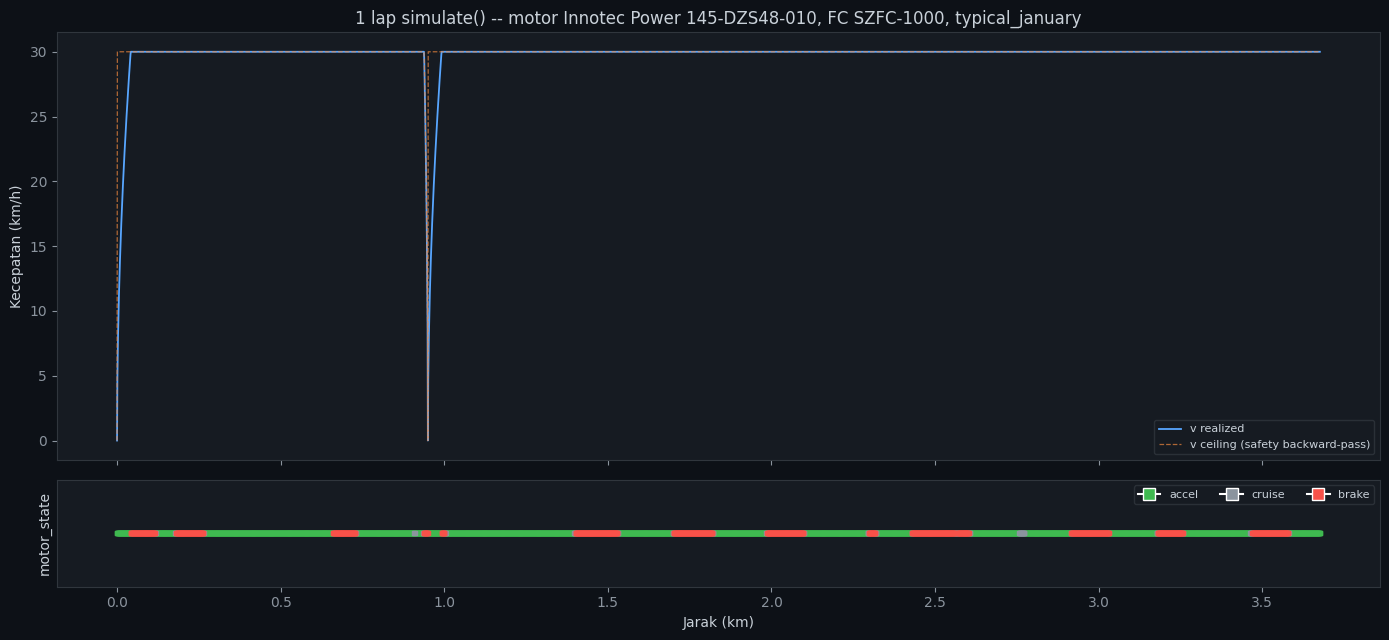

Distribusi motor_state (1 lap, strategi crude cruise-constant):
motor_state
accel     2497
brake     1092
cruise      88


In [11]:
full_track = sim_mod.build_full_attempt_track(profile, laps=1)
motor = motors[config.DEFAULT_MOTOR_NAME]
telemetry = sim_mod.simulate(full_track, scenario, motor=motor, fc=fc)

phase_color = {"accel": "#3fb950", "cruise": "#8b949e", "brake": "#f85149"}
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True,
                                gridspec_kw={"height_ratios": [4, 1]})
ax1.plot(telemetry["distance_km"], telemetry["v_kmh"], color="#58a6ff", linewidth=1.3, label="v realized")
ax1.plot(telemetry["distance_km"], telemetry["v_ceiling_kmh"], color="#f0883e", linewidth=0.9,
         linestyle="--", alpha=0.7, label="v ceiling (safety backward-pass)")
ax1.set_ylabel("Kecepatan (km/h)")
ax1.set_title(f"1 lap simulate() -- motor {config.DEFAULT_MOTOR_NAME}, FC {config.DEFAULT_FC_NAME}, {scenario.name}")
ax1.legend(fontsize=8, loc="lower right")

for phase, color in phase_color.items():
    mask = telemetry["motor_state"] == phase
    ax2.scatter(telemetry.loc[mask, "distance_km"], np.zeros(mask.sum()), color=color, s=8, marker="s")
ax2.set_yticks([])
ax2.set_xlabel("Jarak (km)")
ax2.set_ylabel("motor_state")
handles = [plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=c, markersize=8, label=p)
           for p, c in phase_color.items()]
ax2.legend(handles=handles, loc="upper right", ncol=3, fontsize=8)

plt.tight_layout()
plt.savefig("assets/plot_dt_simulate_sample.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

state_counts = telemetry["motor_state"].value_counts()
print("Distribusi motor_state (1 lap, strategi crude cruise-constant):")
print(state_counts.to_string())

## 7. Tahap 6 — Skor Art. 54e (`telemetry.py`)

Skor resmi kelas Hydrogen Fuel Cell: **km per m³ hidrogen terkonsumsi**. Dua komponen dijumlah sebelum
dibagi jarak: H2 terukur flow-meter (kolom `h2_cumulative_m3`, hasil Tahap 5-6) + H2-ekuivalen dari
energi baterai aksesori yang diukur joulemeter, dikonversi lewat formula resmi contoh Art. 54e (asumsi
efisiensi FC 0.5 untuk konversi ini -- angka ini RULE-DERIVED, diverifikasi mereproduksi hasil 1.855 L
contoh resmi persis, bukan tebakan):

$$\text{skor} = \frac{\text{jarak (km)}}{V_{H_2,flowmeter} + V_{H_2,ekuivalen\ aksesori}} \quad \text{(km/m}^3\text{)}$$

Dihitung dari run 1-lap yang baru saja dijalankan:

In [12]:
total_dist_km = telemetry["distance_km"].iloc[-1]
total_h2_m3 = telemetry["h2_cumulative_m3"].iloc[-1]
total_accessory_j = telemetry["accessory_energy_cumulative_j"].iloc[-1]
accessory_h2_equiv_m3 = telemetry_mod.accessory_h2_equivalent_m3(total_accessory_j)
score = telemetry_mod.h2_score_km_per_m3(total_dist_km, total_h2_m3, accessory_energy_j=total_accessory_j)

print(f"Jarak         : {total_dist_km:.3f} km (1 lap)")
print(f"H2 flow-meter : {total_h2_m3*1000:.4f} L")
print(f"Energi aksesori: {total_accessory_j/1000:.2f} kJ -> {accessory_h2_equiv_m3*1000:.4f} L H2-ekuivalen")
print(f"Skor Art. 54e : {score:.1f} km/m^3 H2  (1 lap, strategi crude -- BUKAN angka strategi optimal,")
print("                 lihat SEM_Digital_Twin_Demo.ipynb untuk hasil DP/GA/dst. 4-lap penuh)")

Jarak         : 3.676 km (1 lap)
H2 flow-meter : 19.5329 L
Energi aksesori: 6.79 kJ -> 1.2594 L H2-ekuivalen
Skor Art. 54e : 176.8 km/m^3 H2  (1 lap, strategi crude -- BUKAN angka strategi optimal,
                 lihat SEM_Digital_Twin_Demo.ipynb untuk hasil DP/GA/dst. 4-lap penuh)


## 8. Menutup Placeholder Tanpa Uji Bangku: Estimasi Efisiensi Drivetrain dari Telemetri Nyata

`DRIVETRAIN_EFFICIENCY_ASSUMED = 0.80` (Tahap 5a) adalah salah satu PLACEHOLDER yang paling
berpengaruh -- ia membagi HAMPIR SETIAP watt yang diminta motor, setiap langkah, sepanjang
attempt. Tidak ada waktu tim untuk uji bangku/dyno khusus -- tapi angka ini sebenarnya bisa
ditutup GRATIS dari satu segmen cruise-konstan telemetri NYATA yang sudah akan direkam tim
untuk keperluan lain:

Pada kecepatan konstan (percepatan ~0), daya roda yang dibutuhkan sudah 100% ditentukan oleh
`vehicle.py` sendiri (drag dari CFD + cuaca, rolling resistance dari CRR yang kini terukur,
grade, cornering) -- TIDAK ADA yang belum diketahui di sisi itu. Kurva efisiensi motor
(Tahap 5) juga sudah diketahui. Jadi cuma ada SATU variabel bebas tersisa yang menjembatani
"daya elektrik yang diprediksi" dengan "daya elektrik yang benar-benar terukur logger" pada
kecepatan itu: `drivetrain_eff`. Itu yang `digital_twin/calibrate.py::estimate_drivetrain_efficiency()`
selesaikan lewat pencarian numerik (`scipy.optimize.minimize_scalar`), meminimalkan selisih
kuadrat prediksi-vs-terukur di setiap baris kecepatan-stabil.

**Validasi metode dulu** (sebelum dipercaya buat data asli): jalankan `simulate()` dengan
`DRIVETRAIN_EFFICIENCY_ASSUMED` DIGANTI SEMENTARA ke satu angka yang kita tahu persis (bukan
0.80 -- angka lain, biar bukan kebetulan), ambil segmen cruise-nya, lalu cek apakah
`estimate_drivetrain_efficiency()` bisa menemukan kembali angka itu HANYA dari `v_kmh` dan
`p_motor_elec_w` segmen tersebut (persis kolom yang tersedia dari telemetri nyata).

In [13]:
from digital_twin import calibrate

TRUE_ETA_FOR_VALIDATION = 0.83  # sengaja BUKAN config.DRIVETRAIN_EFFICIENCY_ASSUMED (0.80),
                                 # supaya kecocokan bukan kebetulan dari nilai default

_orig_eta = config.DRIVETRAIN_EFFICIENCY_ASSUMED
config.DRIVETRAIN_EFFICIENCY_ASSUMED = TRUE_ETA_FOR_VALIDATION
try:
    full_track_1lap = sim_mod.build_full_attempt_track(profile, laps=1)
    synthetic_telemetry = sim_mod.simulate(full_track_1lap, scenario, motor=motor, fc=fc)
finally:
    config.DRIVETRAIN_EFFICIENCY_ASSUMED = _orig_eta  # restore -- jangan bocor ke sel lain

# Segmen cruise-stabil (jauh dari standing-start & 2 stop wajib): ini yang akan
# datang dari telemetri MQTT nyata nantinya, cuma di sini disimulasikan.
cruise_segment = synthetic_telemetry[
    (synthetic_telemetry["distance_km"] > 0.2) & (synthetic_telemetry["distance_km"] < 0.8)
].copy()

result = calibrate.estimate_drivetrain_efficiency(cruise_segment, motor, scenario)
print(f"Segmen cruise: {result['n_points']} baris, v={cruise_segment['v_kmh'].min():.1f}-{cruise_segment['v_kmh'].max():.1f} km/h")
print(f"drivetrain_eff hasil estimasi : {result['drivetrain_eff']:.4f}")
print(f"drivetrain_eff sebenarnya     : {TRUE_ETA_FOR_VALIDATION:.4f}")
print(f"selisih                       : {abs(result['drivetrain_eff'] - TRUE_ETA_FOR_VALIDATION):.5f}")
print(f"RMSE prediksi vs 'terukur'    : {result['rmse_w']:.4f} W")
print()
print("Metode terverifikasi -- begitu ada satu segmen telemetri NYATA cruise-stabil (v_kmh +")
print("p_motor_elec_w dari Batt Voltage x Battery Current logger), panggil fungsi yang sama")
print("untuk angka drivetrain_eff yang sesungguhnya, tanpa uji bangku terpisah.")

Segmen cruise: 599 baris, v=30.0-30.0 km/h
drivetrain_eff hasil estimasi : 0.8300
drivetrain_eff sebenarnya     : 0.8300
selisih                       : 0.00001
RMSE prediksi vs 'terukur'    : 0.0069 W

Metode terverifikasi -- begitu ada satu segmen telemetri NYATA cruise-stabil (v_kmh +
p_motor_elec_w dari Batt Voltage x Battery Current logger), panggil fungsi yang sama
untuk angka drivetrain_eff yang sesungguhnya, tanpa uji bangku terpisah.


## 9. Ringkasan

Tahap-tahap di atas (plus Tahap 8 kalibrasi) adalah **konstruksi** digital twin, dari data mentah sampai satu
angka skor yang bisa dipercaya untuk SATU strategi tertentu:

| Tahap | Modul | Input mentah | Output |
|---|---|---|---|
| 0 | `config.py` | datasheet/rulebook/asumsi tim | konstanta bertag MEASURED/RULE-DERIVED/PLACEHOLDER |
| 1 | `track.py` | GPS+elevasi, turns.csv, citra satelit | profil per-titik (heading, grade, lebar, r_min, stop) |
| 2 | `weather.py` | climate normals Doha/Lusail | 3 skenario named (ρ + headwind per-heading) |
| 3 | `vehicle.py` | CFD CdA + parameter chassis | 4 gaya resistif sebagai fungsi kecepatan |
| 4 | `powertrain.py` | datasheet motor/FC digitized | kurva efisiensi + daya elektrik per motor/FC |
| 5 | `simulate.py` | Tahap 1-4 + 1 strategi kecepatan | telemetri fisik lengkap per titik |
| 6 | `telemetry.py` | telemetri Tahap 5 | skor Art. 54e (km/m³ H2) |
| 8 | `calibrate.py` | segmen telemetri cruise-stabil | drivetrain_eff dari telemetri nyata, bukan uji bangku |

**Yang BUKAN bagian dari digital twin ini** (strategy layer, panggil `simulate()` berkali-kali dari
luar): DP (`optimize_dp.py`), GA/PSO/CMA-ES (`optimize_ga/pso/cma.py`), MPC (`mpc.py`), Fuzzy
(`fuzzy_strategy.py`). Hasil dan perbandingan mereka ada di `SEM_Digital_Twin_Demo.ipynb`,
`ga_analyze.ipynb`, `mpc_analyze.ipynb`, `fuzzy_analyze.ipynb`, `cma_analyze.ipynb` -- notebook ini
sengaja berhenti sebelum strategi dimulai, supaya "bagaimana simulatornya dibangun" dan "strategi apa
yang menang di atasnya" tidak tercampur jadi satu narasi.
